In [1]:
import os
import sys
from pathlib import Path

ROOT = Path(os.getcwd()).resolve().parents[1]  # bart-playground root
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

notebook = "fixed100_Friedman"

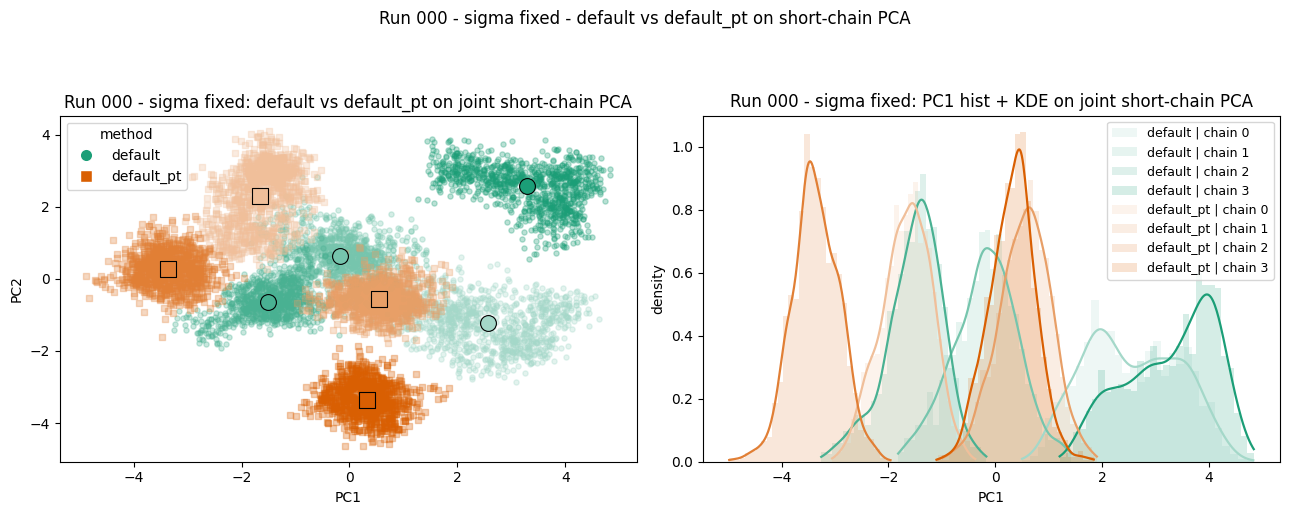

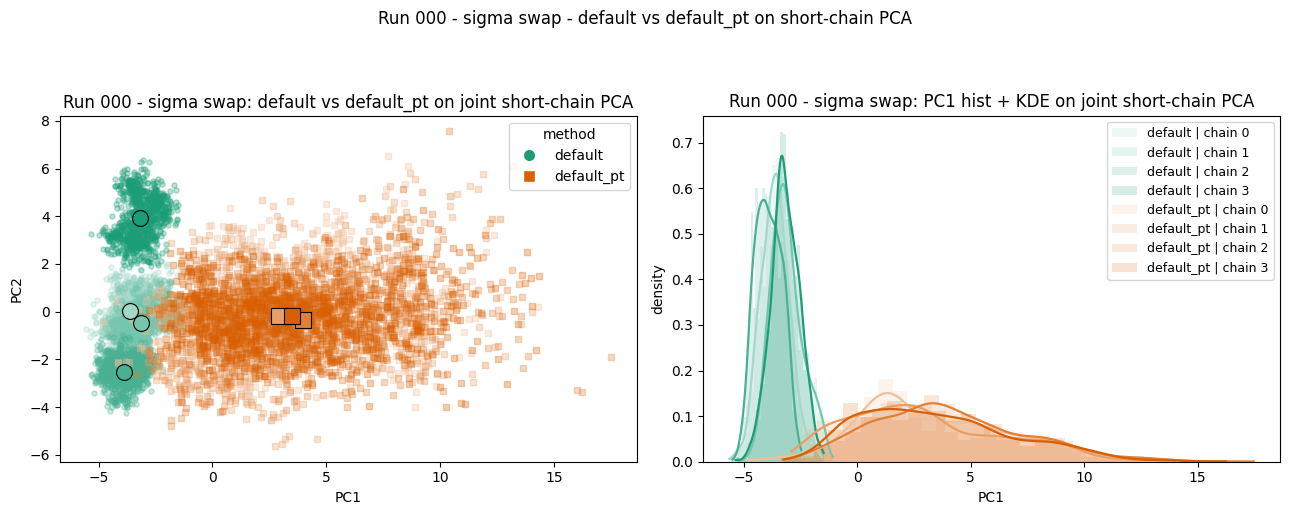

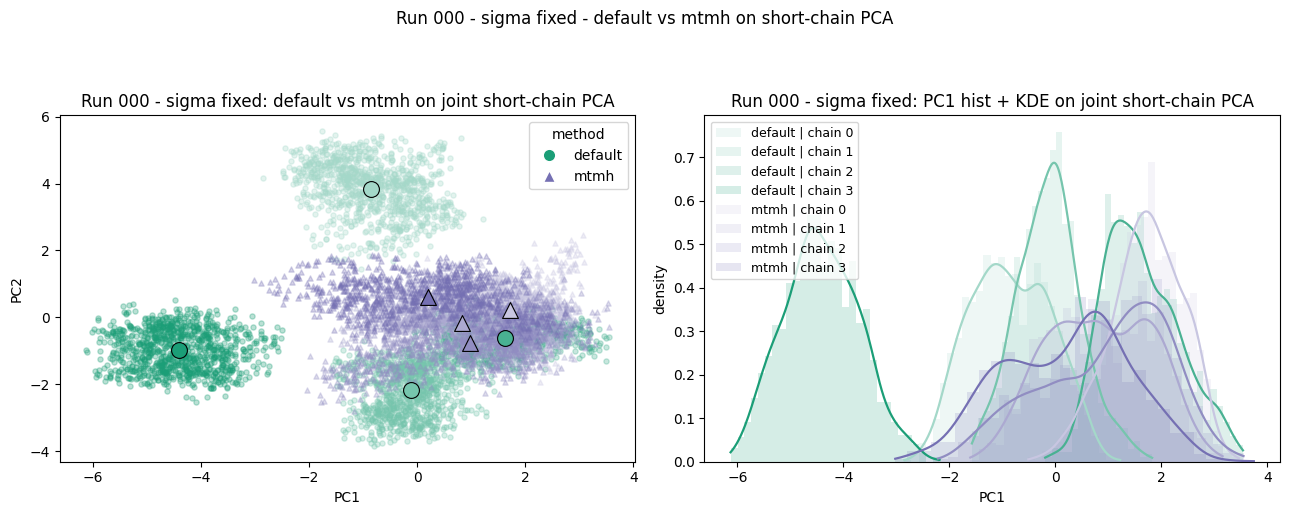

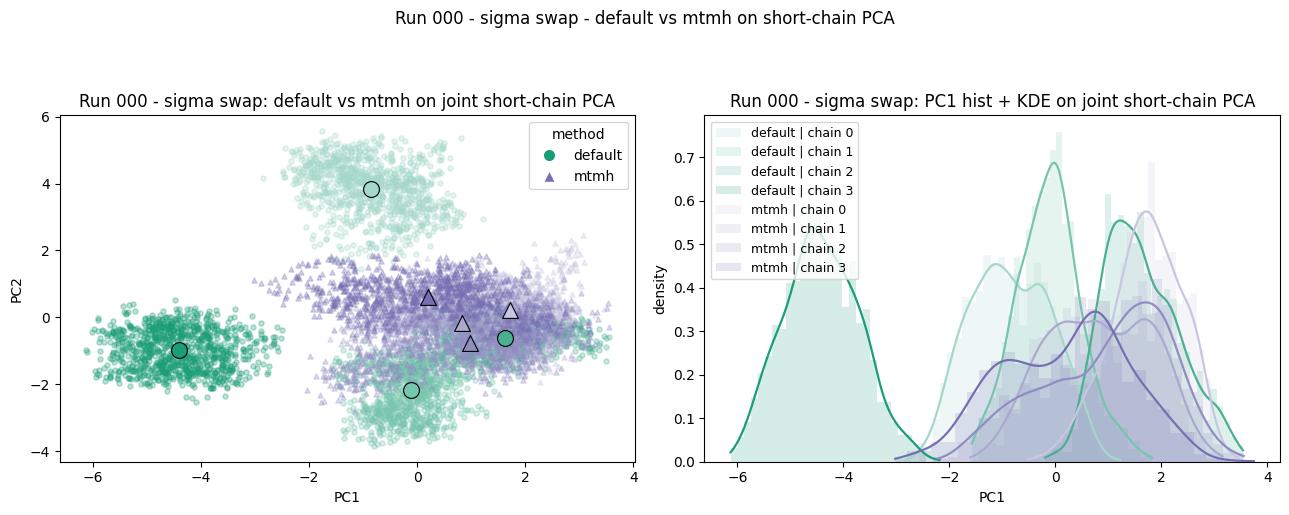

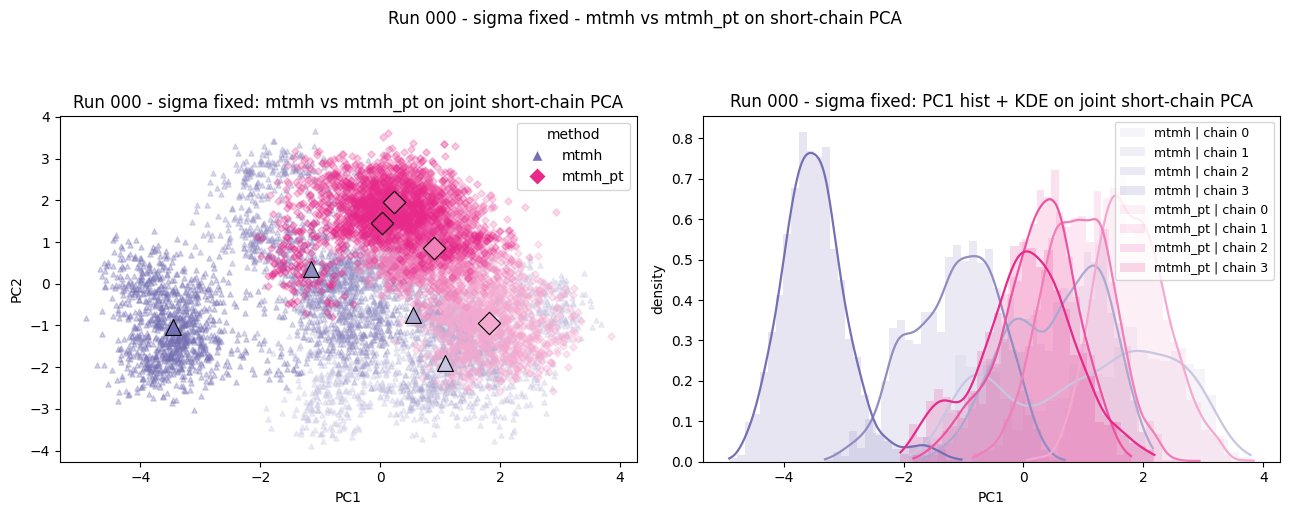

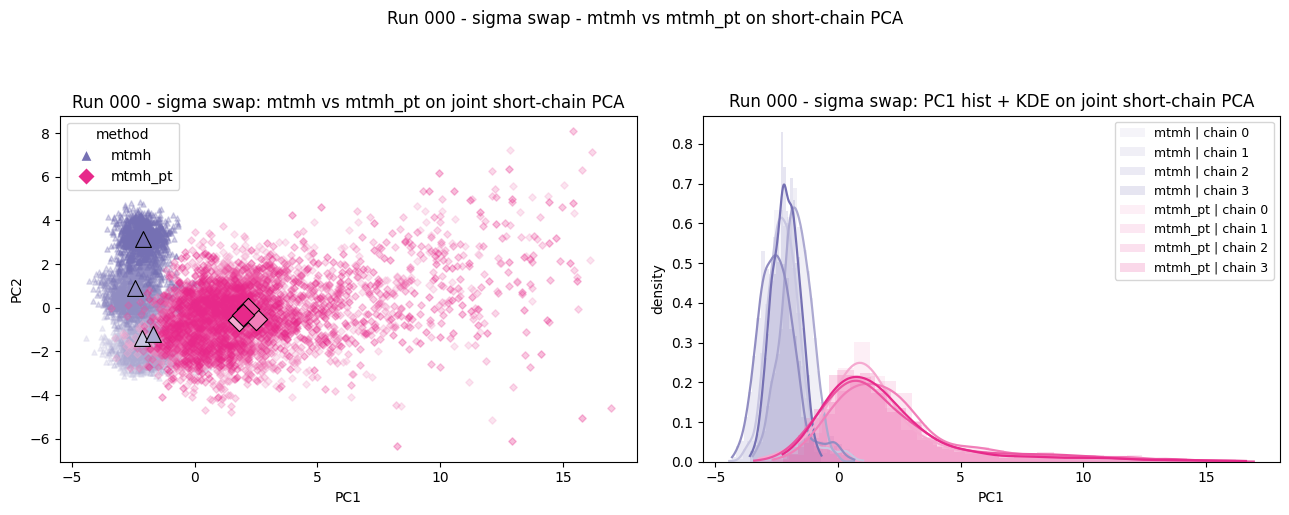

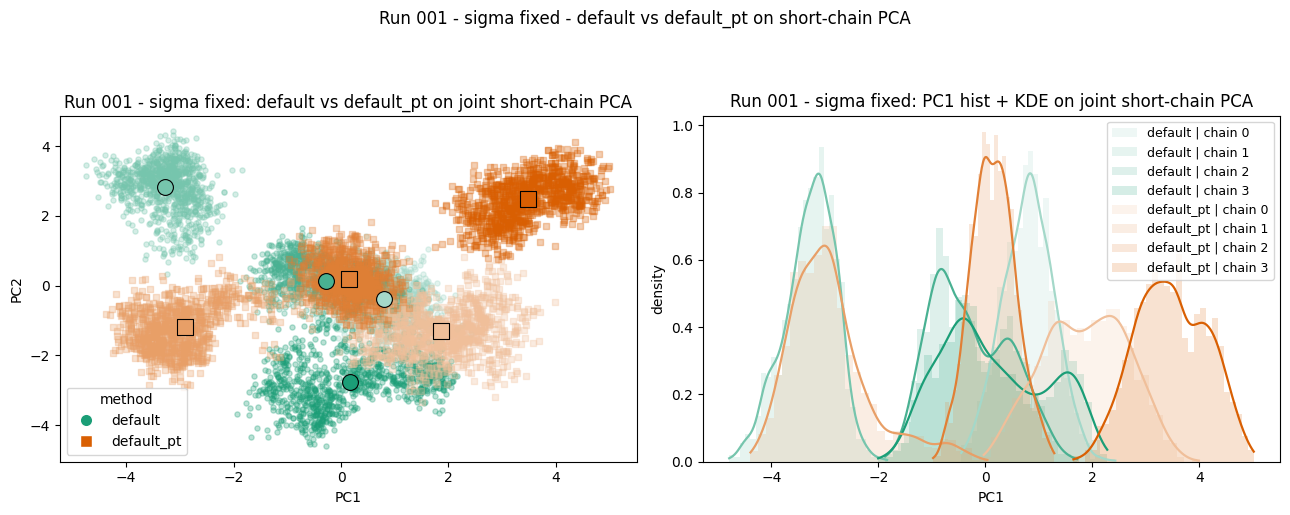

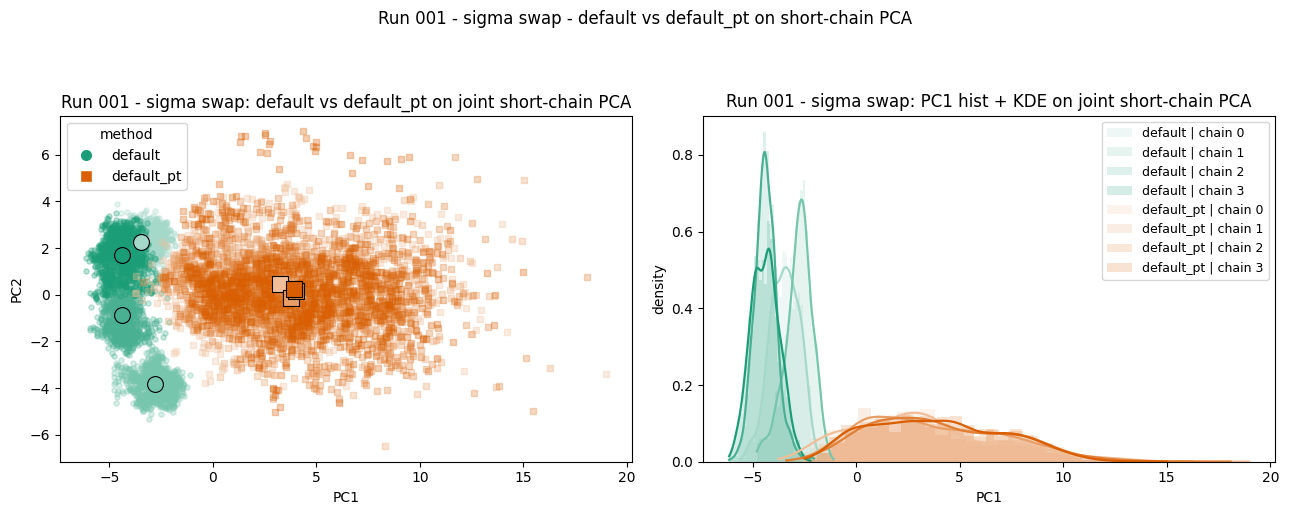

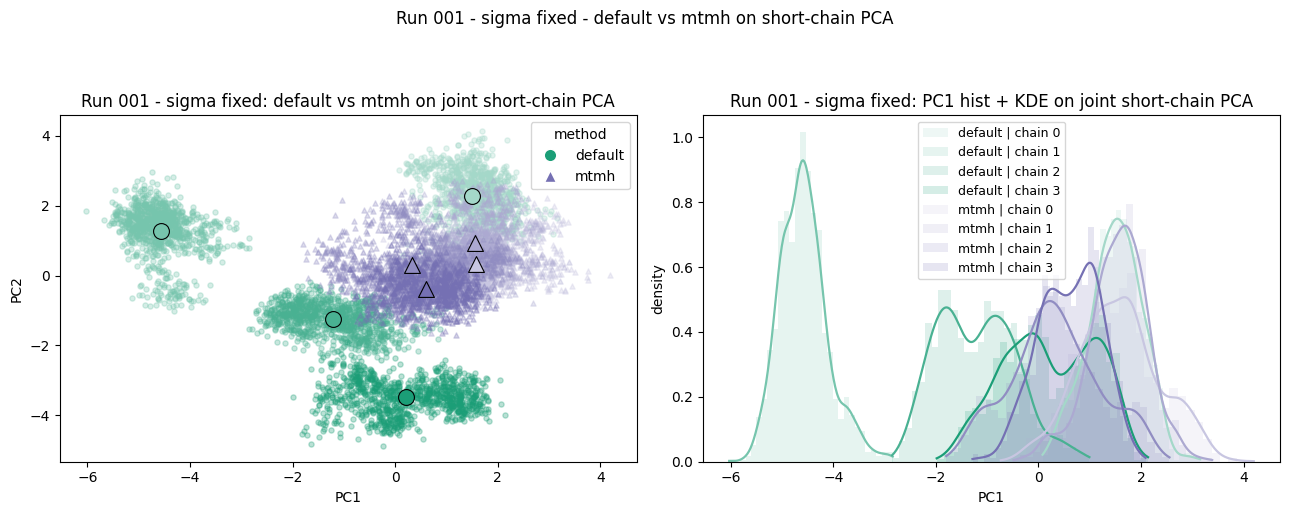

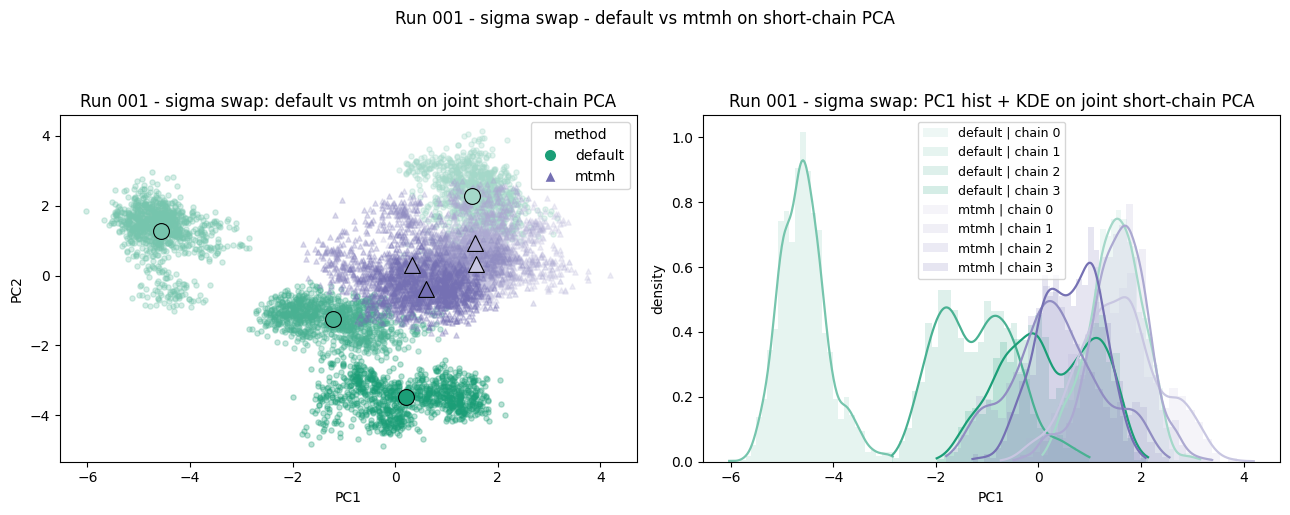

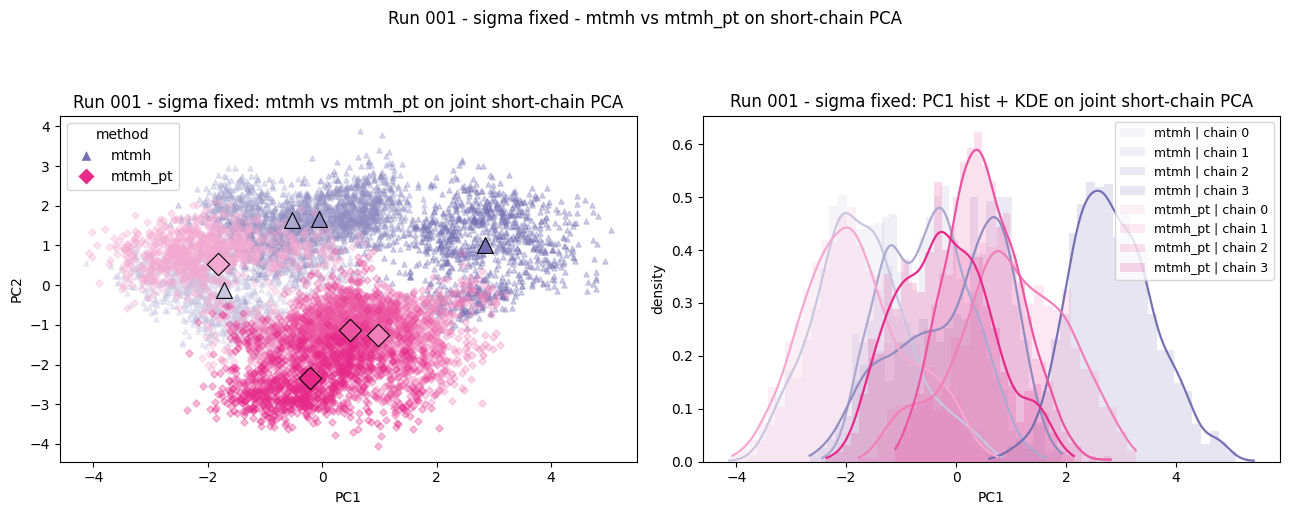

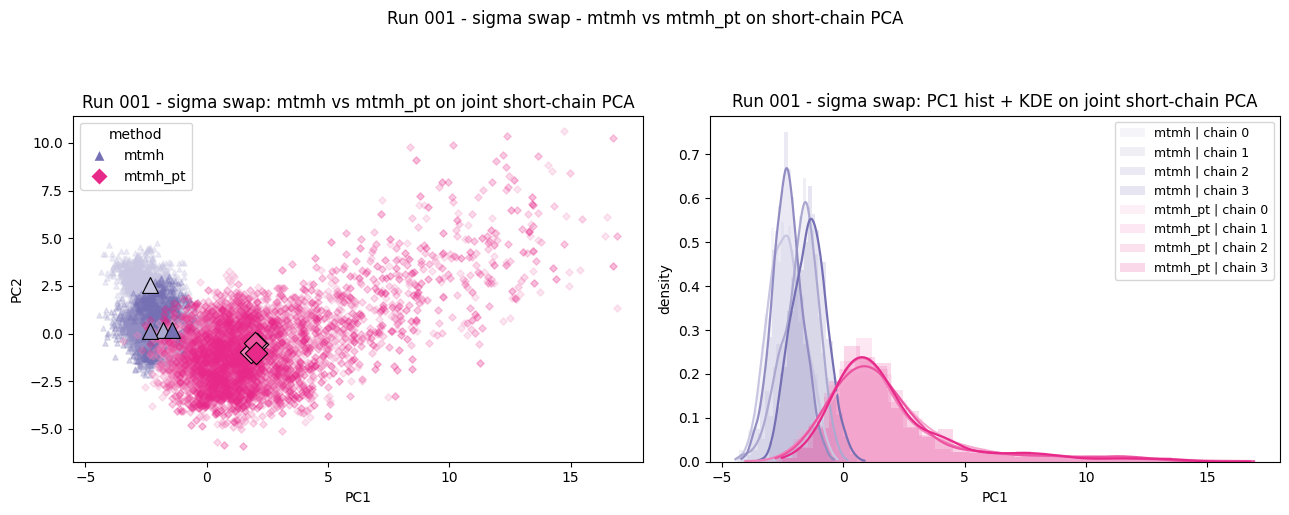

In [2]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

SHORT_BASE_STORE = ROOT / "diagnosis" / "fixed100_testpoints_harmmean" / "store"
SHORT_TAGS = {
    "swap_sigma_false": f"{notebook}__swap_sigma_false",
    "swap_sigma_true": f"{notebook}__swap_sigma_true",
}
SWAP_DISPLAY = {
    "swap_sigma_false": "sigma fixed",
    "swap_sigma_true": "sigma swap",
}

RUN_IDS = [0, 1]  # update if you have more runs
PAIRWISE_COMPARISONS = [
    ("default", "default_pt"),
    ("default", "mtmh"),
    ("mtmh", "mtmh_pt"),
]

BURN_IN = 500
DOWNSAMPLE_PER_CHAIN = 1000
SCATTER_ALPHA = 0.30
METHOD_MARKERS = {
    "default": "o",
    "default_pt": "s",
    "mtmh": "^",
    "mtmh_pt": "D",
}
METHOD_COLORS = {
    "default": "#1b9e77",
    "default_pt": "#d95f02",
    "mtmh": "#7570b3",
    "mtmh_pt": "#e7298a",
}

def _load_with_shape(csv_path: Path):
    with open(csv_path, "r", encoding="utf-8") as f:
        header = f.readline().strip()
    if "original_shape=" not in header:
        raise ValueError(f"Missing original_shape in header: {csv_path}")
    shape_str = header.split("original_shape=")[-1]
    shape = ast.literal_eval(shape_str)
    data = np.loadtxt(csv_path, delimiter=",", comments="#")
    return data, shape

def _load_pred_chains(swap_key: str, run_id: int, method: str):
    short_tag = SHORT_TAGS[swap_key]
    preds_path = SHORT_BASE_STORE / short_tag / "preds" / f"{short_tag}__run{run_id:03d}__{method}__preds.csv"
    preds_raw, preds_shape = _load_with_shape(preds_path)
    preds = preds_raw.reshape(preds_shape)
    chains = []
    for chain_id in range(preds.shape[0]):
        chain_preds = preds[chain_id]
        if BURN_IN > 0:
            chain_preds = chain_preds[:, BURN_IN:]
        chains.append(chain_preds)
    return preds, chains

def _fit_joint_short_pca(swap_key: str, run_id: int, method_a: str, method_b: str):
    _, method_a_chains = _load_pred_chains(swap_key, run_id, method_a)
    _, method_b_chains = _load_pred_chains(swap_key, run_id, method_b)
    joint_blocks = [chain_preds.T for chain_preds in method_a_chains + method_b_chains]
    joint_predictions = np.vstack(joint_blocks)
    pca = PCA(n_components=2, random_state=0)
    pca.fit(joint_predictions)
    return pca, {method_a: method_a_chains, method_b: method_b_chains}

def _method_chain_shades(base_hex, n):
    base = np.array(mcolors.to_rgb(base_hex))
    if n == 1:
        return [tuple(base)]
    shades = []
    for i in range(n):
        t = 0.4 + 0.6 * (i / max(1, n - 1))
        rgb = tuple(base * t + (1 - t) * np.array([1.0, 1.0, 1.0]))
        shades.append(rgb)
    return shades

def _plot_pc1_hist_kde(ax, items, title):
    for label, color, data in items:
        data = np.asarray(data)
        ax.hist(data, bins=30, density=True, alpha=0.18, color=color, label=label)
        try:
            kde = gaussian_kde(data)
            xs = np.linspace(np.min(data), np.max(data), 200)
            ax.plot(xs, kde(xs), color=color, linewidth=1.6)
        except Exception:
            pass

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("density")
    ax.legend(fontsize=9)

def _scatter_method_chains(ax, pca, method_chains, method_name, title):
    marker = METHOD_MARKERS.get(method_name, "o")
    base_color = METHOD_COLORS.get(method_name, "#333333")
    n_chains = len(method_chains)
    shades = _method_chain_shades(base_color, n_chains)
    rng = np.random.default_rng(0)

    for chain_id, chain_preds in enumerate(method_chains):
        chain_color = shades[chain_id % len(shades)]
        coords = pca.transform(chain_preds.T)
        if DOWNSAMPLE_PER_CHAIN is not None and DOWNSAMPLE_PER_CHAIN < coords.shape[0]:
            idx = rng.choice(coords.shape[0], size=DOWNSAMPLE_PER_CHAIN, replace=False)
        else:
            idx = np.arange(coords.shape[0])
        ax.scatter(coords[idx, 0], coords[idx, 1], marker=marker, s=14, alpha=SCATTER_ALPHA, color=chain_color, label="_nolegend_")
        centroid = np.mean(coords, axis=0)
        ax.scatter(
            centroid[0],
            centroid[1],
            marker=marker,
            s=130,
            color=chain_color,
            edgecolor="black",
            linewidth=0.8,
            label=f"{method_name} | chain {chain_id}",
            zorder=5,
        )

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

for run_id in RUN_IDS:
    for method_a, method_b in PAIRWISE_COMPARISONS:
        for swap_key in ["swap_sigma_false", "swap_sigma_true"]:
            joint_pca, method_groups = _fit_joint_short_pca(swap_key, run_id, method_a, method_b)

            fig, axes = plt.subplots(1, 2, figsize=(13, 5))

            for method_name, method_chains in method_groups.items():
                _scatter_method_chains(
                    axes[0],
                    joint_pca,
                    method_chains,
                    method_name,
                    title=f"Run {run_id:03d} - {SWAP_DISPLAY[swap_key]}: {method_a} vs {method_b} on joint short-chain PCA",
                )

            legend_handles = [
                Line2D([0], [0], marker=METHOD_MARKERS[m], color="w", markerfacecolor=METHOD_COLORS[m], markersize=9, label=m)
                for m in method_groups.keys()
            ]
            axes[0].legend(handles=legend_handles, title="method")

            items = []
            for method_name, method_chains in method_groups.items():
                base_color = METHOD_COLORS.get(method_name, "#333333")
                shades = _method_chain_shades(base_color, len(method_chains))
                for cidx, chain_preds in enumerate(method_chains):
                    pc1 = joint_pca.transform(chain_preds.T)[:, 0]
                    items.append((f"{method_name} | chain {cidx}", shades[cidx % len(shades)], pc1))

            _plot_pc1_hist_kde(
                axes[1],
                items,
                title=f"Run {run_id:03d} - {SWAP_DISPLAY[swap_key]}: PC1 hist + KDE on joint short-chain PCA",
            )

            fig.suptitle(f"Run {run_id:03d} - {SWAP_DISPLAY[swap_key]} - {method_a} vs {method_b} on short-chain PCA", y=1.02)
            fig.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()

In [3]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

SHORT_BASE_STORE = ROOT / "diagnosis" / "fixed100_testpoints_harmmean" / "store"

SHORT_TAGS = {
    "swap_sigma_false": f"{notebook}__swap_sigma_false",
    "swap_sigma_true": f"{notebook}__swap_sigma_true",
}

SHORT_GROUP_NAMES = {
    "swap_sigma_false": "Short (sigma fixed)",
    "swap_sigma_true": "Short (sigma swap)",
}

SHORT_METHODS = ["default", "default_pt", "mtmh", "mtmh_pt"]
SHORT_METHOD_NAMES = {
    "default": "Default",
    "default_pt": "Default PT",
    "mtmh": "MTMH",
    "mtmh_pt": "MTMH + PT",
}

SHORT_BURN_IN = 500

METHOD_LABELS = {
    ("swap_sigma_false", "default"): "Default (2k, sigma fixed)",
    ("swap_sigma_false", "default_pt"): "Default PT (2k, sigma fixed)",
    ("swap_sigma_false", "mtmh"): "MTMH (2k, sigma fixed)",
    ("swap_sigma_false", "mtmh_pt"): "MTMH + PT (2k, sigma fixed)",
    ("swap_sigma_true", "default"): "Default (2k, sigma swap)",
    ("swap_sigma_true", "default_pt"): "Default PT (2k, sigma swap)",
    ("swap_sigma_true", "mtmh"): "MTMH (2k, sigma swap)",
    ("swap_sigma_true", "mtmh_pt"): "MTMH + PT (2k, sigma swap)",
}


def _load_with_shape(csv_path: Path):
    with open(csv_path, "r", encoding="utf-8") as f:
        header = f.readline().strip()
    if "original_shape=" not in header:
        raise ValueError(f"Missing original_shape in header: {csv_path}")
    shape_str = header.split("original_shape=")[-1]
    shape = ast.literal_eval(shape_str)
    data = np.loadtxt(csv_path, delimiter=",", comments="#")
    return data, shape


def _crps_from_samples(samples, y_true):
    samples = np.asarray(samples)
    y_true = np.asarray(y_true)
    n_points, n_samples = samples.shape
    term1 = np.mean(np.abs(samples - y_true[:, None]), axis=1)
    samples_sorted = np.sort(samples, axis=1)
    k = np.arange(1, n_samples + 1)
    coeffs = (2 * k - n_samples - 1)[None, :]
    term2 = np.sum(coeffs * samples_sorted, axis=1) / (n_samples**2)
    return term1 - term2


def _load_prediction_chains(base_store: Path, tag: str, run_id: int, method: str, burn_in: int):
    preds_path = base_store / tag / "preds" / f"{tag}__run{run_id:03d}__{method}__preds.csv"
    preds_raw, preds_shape = _load_with_shape(preds_path)
    preds = preds_raw.reshape(preds_shape)
    chains = []
    for chain_id in range(preds.shape[0]):
        chain_preds = preds[chain_id]
        if burn_in > 0:
            chain_preds = chain_preds[:, burn_in:]
        chains.append(chain_preds)
    return preds, chains


def _load_subsample_y(base_store: Path, tag: str, run_id: int):
    y_path = base_store / tag / "subsample_y_test" / f"{tag}__run{run_id:03d}__subsample_y_test.csv"
    y_raw, y_shape = _load_with_shape(y_path)
    return np.asarray(y_raw.reshape(y_shape)).reshape(-1)


def _available_run_ids(base_store: Path, tag: str, method: str):
    preds_dir = base_store / tag / "preds"
    run_ids = []
    for path in preds_dir.glob(f"{tag}__run*__{method}__preds.csv"):
        parts = path.name.split("__run")
        if len(parts) < 2:
            continue
        run_fragment = parts[1].split("__", 1)[0]
        try:
            run_ids.append(int(run_fragment))
        except ValueError:
            continue
    return sorted(set(run_ids))


def _chain_metric_row(chain_preds, y_true):
    y_pred = np.mean(chain_preds, axis=1)
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    crps = float(np.mean(_crps_from_samples(chain_preds, y_true)))
    return rmse, crps


def _grouped_view(metric_df):
    groups = {}
    for swap_key in ["swap_sigma_false", "swap_sigma_true"]:
        group_name = SHORT_GROUP_NAMES[swap_key]
        for method in SHORT_METHODS:
            full_label = METHOD_LABELS[(swap_key, method)]
            short_label = SHORT_METHOD_NAMES[method]
            groups[(group_name, short_label)] = metric_df[full_label]
    grouped_df = pd.DataFrame(groups, index=metric_df.index)
    grouped_df.columns = pd.MultiIndex.from_tuples(grouped_df.columns)
    return grouped_df


run_id_sets = []
for swap_key, short_tag in SHORT_TAGS.items():
    for method in SHORT_METHODS:
        run_id_sets.append(set(_available_run_ids(SHORT_BASE_STORE, short_tag, method)))
run_ids = sorted(set.intersection(*run_id_sets)) if run_id_sets else []
if not run_ids:
    raise FileNotFoundError("No overlapping runs found for short-chain swap/no-swap groups.")

rmse_rows = []
crps_rows = []

for run_id in run_ids:
    y_by_swap = {}
    for swap_key, short_tag in SHORT_TAGS.items():
        y_by_swap[swap_key] = _load_subsample_y(SHORT_BASE_STORE, short_tag, run_id)

    y_ref = y_by_swap["swap_sigma_false"]
    y_other = y_by_swap["swap_sigma_true"]
    if y_ref.shape != y_other.shape or not np.allclose(y_ref, y_other):
        raise ValueError(f"Run {run_id:03d} has mismatched subsample_y_test between short swap settings.")

    rmse_row = {"run": f"Run {run_id:03d}"}
    crps_row = {"run": f"Run {run_id:03d}"}

    for swap_key, short_tag in SHORT_TAGS.items():
        y_true = y_by_swap[swap_key]
        for method in SHORT_METHODS:
            _, short_chains = _load_prediction_chains(
                SHORT_BASE_STORE, short_tag, run_id, method, SHORT_BURN_IN
            )
            rmse_vals = []
            crps_vals = []
            for chain_preds in short_chains:
                rmse_val, crps_val = _chain_metric_row(chain_preds, y_true)
                rmse_vals.append(rmse_val)
                crps_vals.append(crps_val)
            label = METHOD_LABELS[(swap_key, method)]
            rmse_row[label] = float(np.mean(rmse_vals))
            crps_row[label] = float(np.mean(crps_vals))

    rmse_rows.append(rmse_row)
    crps_rows.append(crps_row)

rmse_df = pd.DataFrame(rmse_rows).set_index("run")
crps_df = pd.DataFrame(crps_rows).set_index("run")

column_order = []
for swap_key in ["swap_sigma_false", "swap_sigma_true"]:
    for method in SHORT_METHODS:
        column_order.append(METHOD_LABELS[(swap_key, method)])

rmse_df = rmse_df[column_order]
crps_df = crps_df[column_order]

rmse_grouped_df = _grouped_view(rmse_df)
crps_grouped_df = _grouped_view(crps_df)

print("RMSE (grouped view, short-chain only)")
display(rmse_grouped_df.round(4))
print("\nCRPS (grouped view, short-chain only)")
display(crps_grouped_df.round(4))

print("\nRMSE average across runs")
display(rmse_grouped_df.mean(axis=0).unstack(0).T.round(4))
print("\nCRPS average across runs")
display(crps_grouped_df.mean(axis=0).unstack(0).T.round(4))

RMSE (grouped view, short-chain only)


Short (sigma fixed)                              Short (sigma swap)  \
                    Default Default PT    MTMH MTMH + PT            Default   
run                                                                           
Run 000              1.1821     1.1330  1.1155    1.1283             1.1821   
Run 001              1.1608     1.1972  1.1832    1.1962             1.1608   

                                      
        Default PT    MTMH MTMH + PT  
run                                   
Run 000     1.2487  1.1155    1.0807  
Run 001     1.2821  1.1832    1.1301


CRPS (grouped view, short-chain only)


Short (sigma fixed)                              Short (sigma swap)  \
                    Default Default PT    MTMH MTMH + PT            Default   
run                                                                           
Run 000              0.7586     0.7100  0.6934    0.6954             0.7586   
Run 001              0.7279     0.7523  0.7418    0.7357             0.7279   

                                      
        Default PT    MTMH MTMH + PT  
run                                   
Run 000     0.7034  0.6934    0.6119  
Run 001     0.7193  0.7418    0.6387


RMSE average across runs


,Default,Default PT,MTMH,MTMH + PT
Short (sigma fixed),1.1715,1.1651,1.1493,1.1623
Short (sigma swap),1.1715,1.2654,1.1493,1.1054



CRPS average across runs


,Default,Default PT,MTMH,MTMH + PT
Short (sigma fixed),0.7432,0.7311,0.7176,0.7155
Short (sigma swap),0.7432,0.7114,0.7176,0.6253


# Confidence Interval

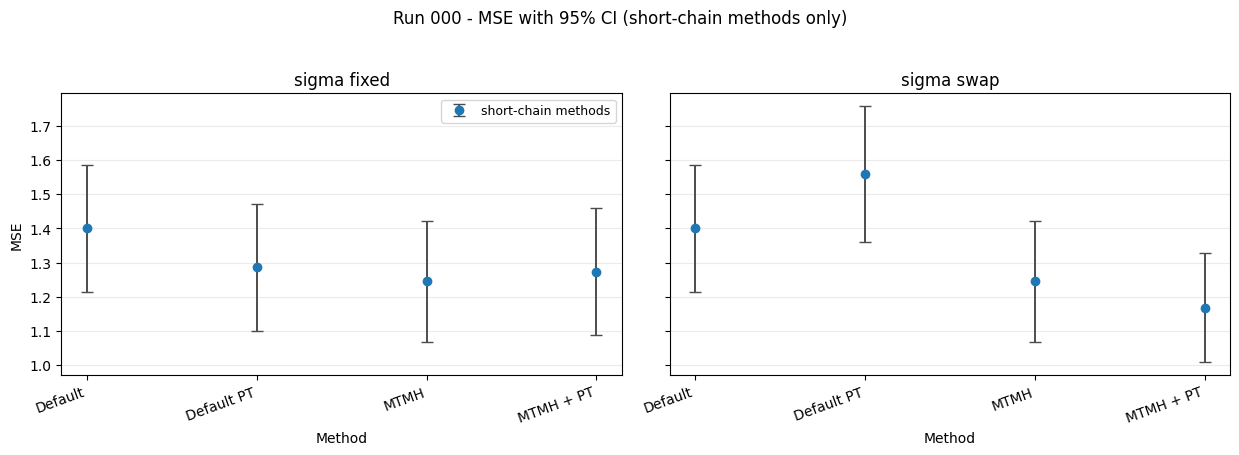

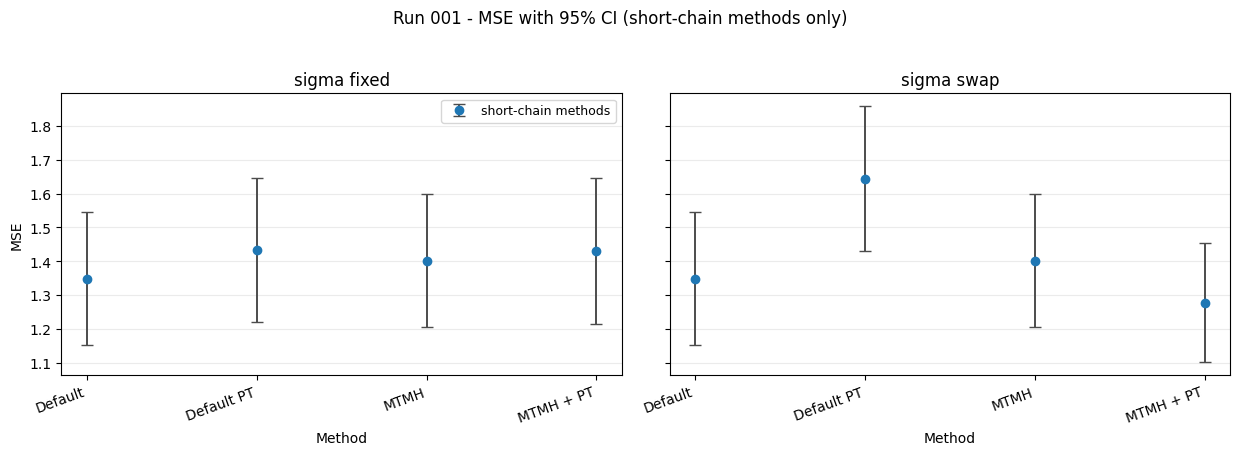

In [4]:
import matplotlib.pyplot as plt

Z_VALUE = 1.96
SWAP_ORDER = ["swap_sigma_false", "swap_sigma_true"]
SWAP_DISPLAY = {
    "swap_sigma_false": "sigma fixed",
    "swap_sigma_true": "sigma swap",
}
SHORT_METHOD_DISPLAY = {
    "default": "Default",
    "default_pt": "Default PT",
    "mtmh": "MTMH",
    "mtmh_pt": "MTMH + PT",
}

run_id_sets = []
for swap_key, short_tag in SHORT_TAGS.items():
    for method in SHORT_METHODS:
        run_id_sets.append(set(_available_run_ids(SHORT_BASE_STORE, short_tag, method)))
run_ids = sorted(set.intersection(*run_id_sets)) if run_id_sets else []
if not run_ids:
    raise FileNotFoundError("No overlapping runs found for short-chain swap/no-swap groups.")

def _mse_mean_ci(square_error_list):
    squared_errors = np.concatenate(square_error_list)
    mse_mean = float(np.mean(squared_errors))
    mse_std = float(np.std(squared_errors, ddof=1)) if squared_errors.size > 1 else 0.0
    ci_half_width = Z_VALUE * mse_std / np.sqrt(squared_errors.size) if squared_errors.size > 1 else 0.0
    return mse_mean, ci_half_width

for run_id in run_ids:
    y_by_swap = {}
    for swap_key, short_tag in SHORT_TAGS.items():
        y_by_swap[swap_key] = _load_subsample_y(SHORT_BASE_STORE, short_tag, run_id)

    y_ref = y_by_swap["swap_sigma_false"]
    y_other = y_by_swap["swap_sigma_true"]
    if y_ref.shape != y_other.shape or not np.allclose(y_ref, y_other):
        raise ValueError(f"Run {run_id:03d} has mismatched subsample_y_test between short swap settings.")

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)

    for ax, swap_key in zip(axes, SWAP_ORDER):
        short_tag = SHORT_TAGS[swap_key]
        y_true = y_by_swap[swap_key]
        means = []
        cis = []

        for method in SHORT_METHODS:
            _, short_chains = _load_prediction_chains(
                SHORT_BASE_STORE, short_tag, run_id, method, SHORT_BURN_IN
            )
            method_sq_errors = []
            for chain_preds in short_chains:
                y_pred = np.mean(chain_preds, axis=1)
                method_sq_errors.append((y_pred - y_true) ** 2)
            m, c = _mse_mean_ci(method_sq_errors)
            means.append(m)
            cis.append(c)

        x = np.arange(len(SHORT_METHODS))
        ax.errorbar(
            x,
            means,
            yerr=cis,
            fmt="o",
            color="#1f77b4",
            ecolor="#4c4c4c",
            elinewidth=1.4,
            capsize=4,
            markersize=6,
            linewidth=0,
            label="short-chain methods",
        )

        ax.set_xticks(x)
        ax.set_xticklabels([SHORT_METHOD_DISPLAY[m] for m in SHORT_METHODS], rotation=20, ha="right")
        ax.set_title(SWAP_DISPLAY[swap_key])
        ax.grid(axis="y", alpha=0.25)
        ax.set_xlabel("Method")

    axes[0].set_ylabel("MSE")
    axes[0].legend(loc="best", fontsize=9)
    fig.suptitle(f"Run {run_id:03d} - MSE with 95% CI (short-chain methods only)")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# LDA: Chain-Labeled Analysis

This section adds a supervised diagnostic using LDA where **chain id** is the class label within the same run.

- We fit LDA separately for each `(run, swap setting, method)`.
- We compare `swap_sigma_false` vs `swap_sigma_true` under the same run and method.
- We compare four methods (`default`, `default_pt`, `mtmh`, `mtmh_pt`) under the same run and swap setting.

Interpretation note: this is an exploratory chain-separation view in prediction space, not a formal convergence proof.

In [5]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

LDA_SWAP_ORDER = ["swap_sigma_false", "swap_sigma_true"]
LDA_MAX_DRAWS_PER_CHAIN = 1500
LDA_RANDOM_SEED = 2028


def _build_chain_labeled_matrix(swap_key: str, run_id: int, method: str, max_draws_per_chain=None, seed=0):
    """Return X, y for LDA where labels are chain ids."""
    short_tag = SHORT_TAGS[swap_key]
    preds_raw, preds_chains = _load_prediction_chains(
        SHORT_BASE_STORE, short_tag, run_id, method, SHORT_BURN_IN
    )

    n_chains, n_points, n_draws = preds_raw.shape
    rng = np.random.default_rng(seed)

    blocks = []
    labels = []
    draw_ids = []

    for chain_id in range(n_chains):
        chain_preds = preds_chains[chain_id]  # (n_points, n_draws)
        available_draws = chain_preds.shape[1]
        if max_draws_per_chain is not None and max_draws_per_chain < available_draws:
            sel = np.sort(rng.choice(available_draws, size=max_draws_per_chain, replace=False))
        else:
            sel = np.arange(available_draws)

        block = chain_preds[:, sel].T  # (n_selected_draws, n_points)
        blocks.append(block)
        labels.append(np.full(block.shape[0], chain_id, dtype=int))
        draw_ids.append(sel)

    X = np.vstack(blocks)
    y = np.concatenate(labels)
    draw_idx = np.concatenate(draw_ids)
    return X, y, draw_idx


def _fit_chain_lda(X, y, n_components=2):
    classes = np.unique(y)
    if classes.size < 2:
        raise ValueError("LDA requires at least two chain classes.")

    max_components = min(classes.size - 1, X.shape[1])
    n_use = min(n_components, max_components)
    if n_use < 1:
        n_use = 1

    model = make_pipeline(
        StandardScaler(),
        LinearDiscriminantAnalysis(n_components=n_use, solver="svd"),
    )
    Z = model.fit_transform(X, y)
    return Z, model


def _method_name(method_key: str):
    return SHORT_METHOD_DISPLAY.get(method_key, method_key)


def _swap_name(swap_key: str):
    return SWAP_DISPLAY.get(swap_key, swap_key)


def _chain_colors_for_method(method_key: str, n_chains: int):
    base_color = METHOD_COLORS.get(method_key, "#333333")
    return _method_chain_shades(base_color, n_chains)


def _chain_separation_metrics(Z, y):
    y = np.asarray(y)
    Z = np.asarray(Z)

    classes = np.unique(y)
    centroids = []
    within_vals = []

    for c in classes:
        points = Z[y == c]
        centroid = points.mean(axis=0)
        centroids.append(centroid)
        within_vals.append(np.mean(np.sum((points - centroid) ** 2, axis=1)))

    centroids = np.vstack(centroids)
    if centroids.shape[0] > 1:
        pairwise = []
        for i in range(centroids.shape[0]):
            for j in range(i + 1, centroids.shape[0]):
                pairwise.append(float(np.linalg.norm(centroids[i] - centroids[j])))
        mean_centroid_dist = float(np.mean(pairwise))
    else:
        mean_centroid_dist = np.nan

    global_center = Z.mean(axis=0)
    between = 0.0
    for c, centroid in zip(classes, centroids):
        n_c = np.sum(y == c)
        between += n_c * float(np.sum((centroid - global_center) ** 2))
    between /= max(1, Z.shape[0])

    within = float(np.mean(within_vals)) if within_vals else np.nan
    sep_ratio = between / within if within and within > 0 else np.nan

    return {
        "mean_centroid_distance": mean_centroid_dist,
        "between_within_ratio": float(sep_ratio) if np.isfinite(sep_ratio) else np.nan,
    }


def _lda_explained_var_ld1(model):
    lda = model.named_steps.get("lineardiscriminantanalysis")
    if lda is None:
        return np.nan
    if hasattr(lda, "explained_variance_ratio_"):
        evr = np.asarray(lda.explained_variance_ratio_)
        if evr.size:
            return float(evr[0])
    return np.nan

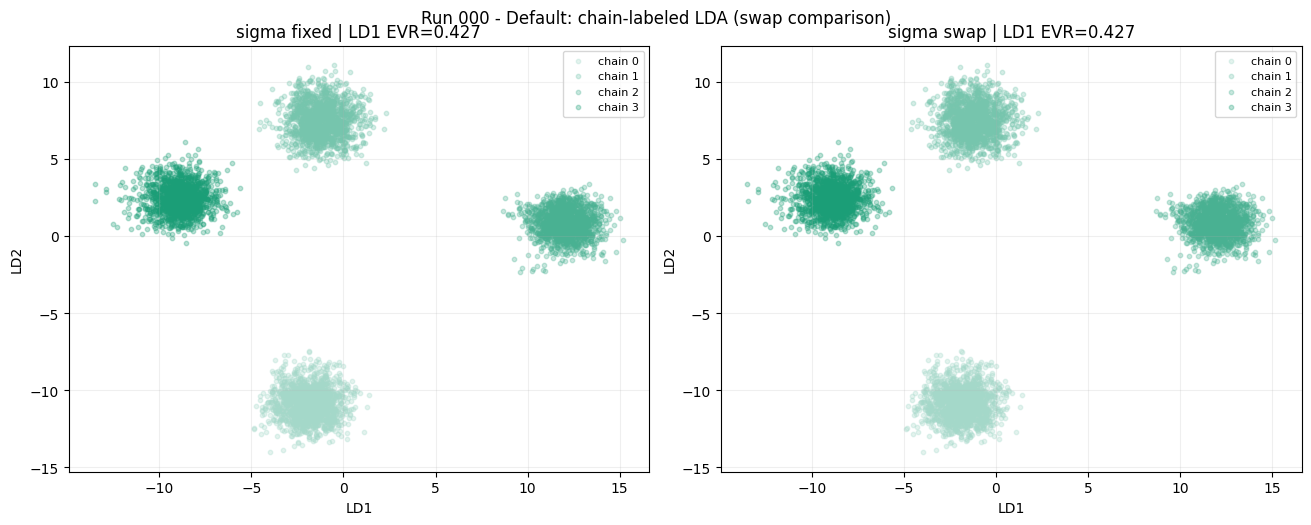

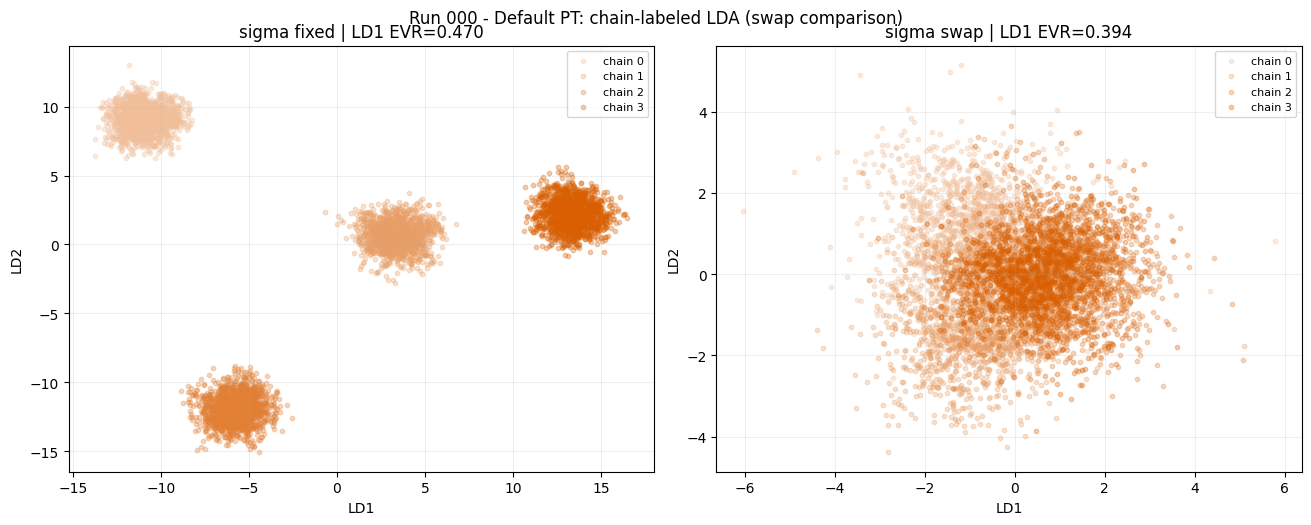

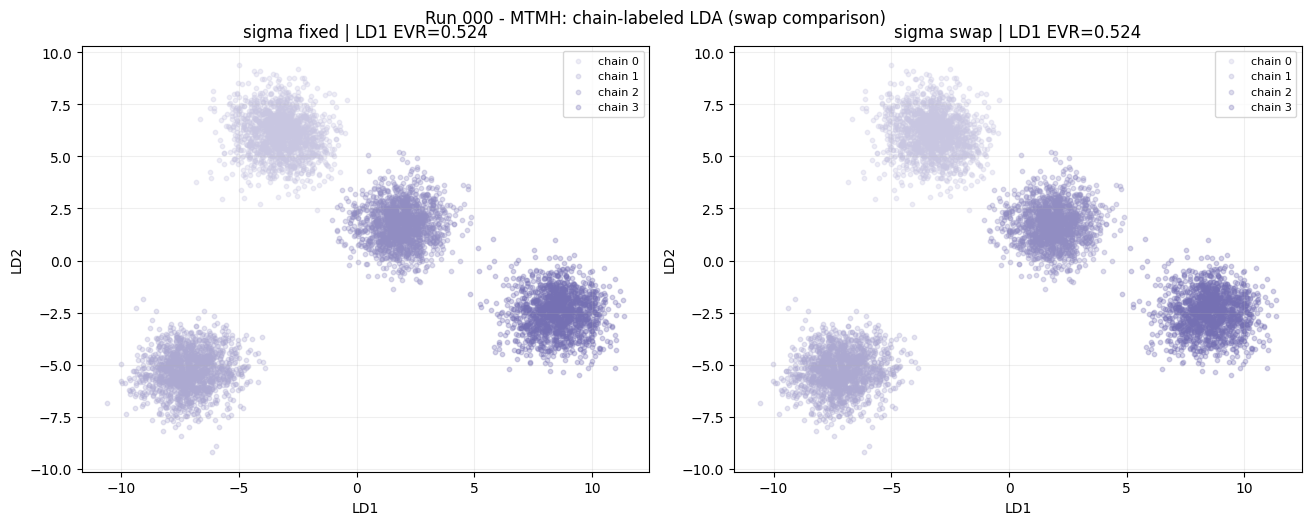

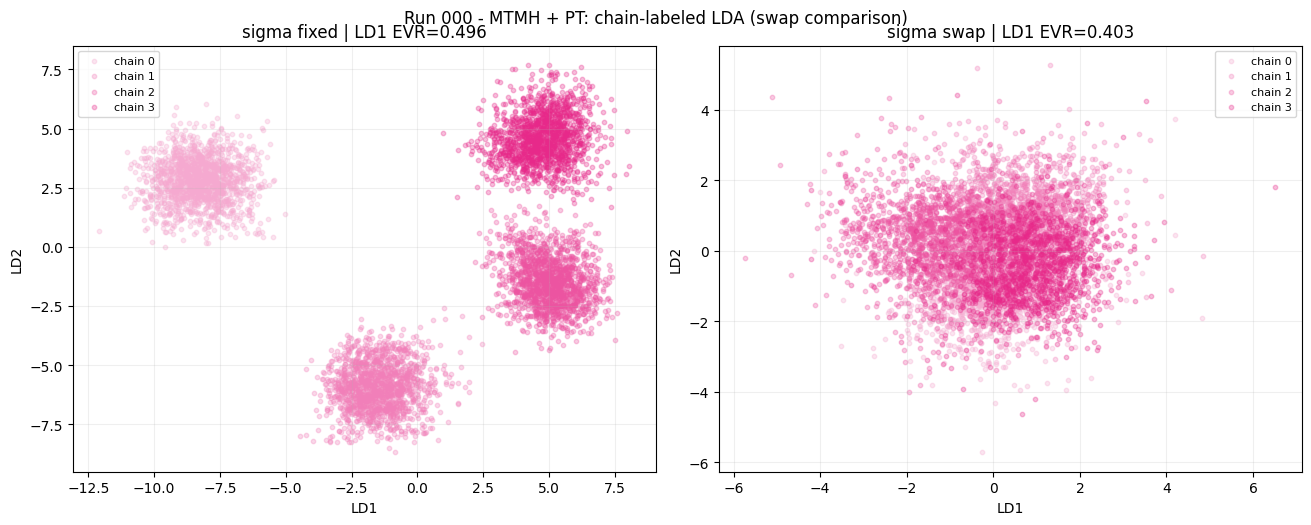

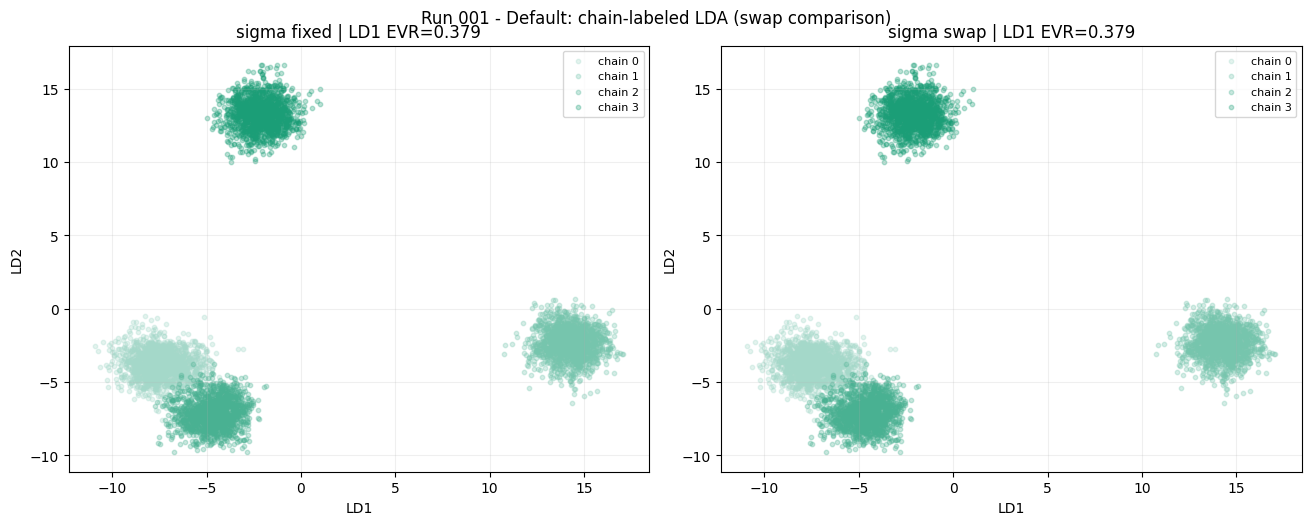

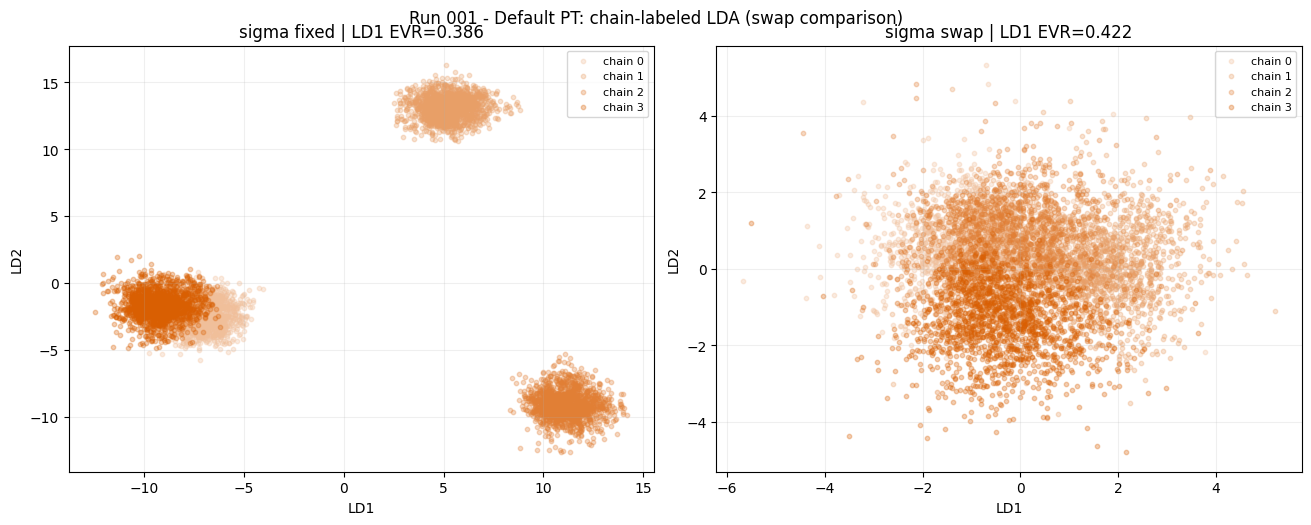

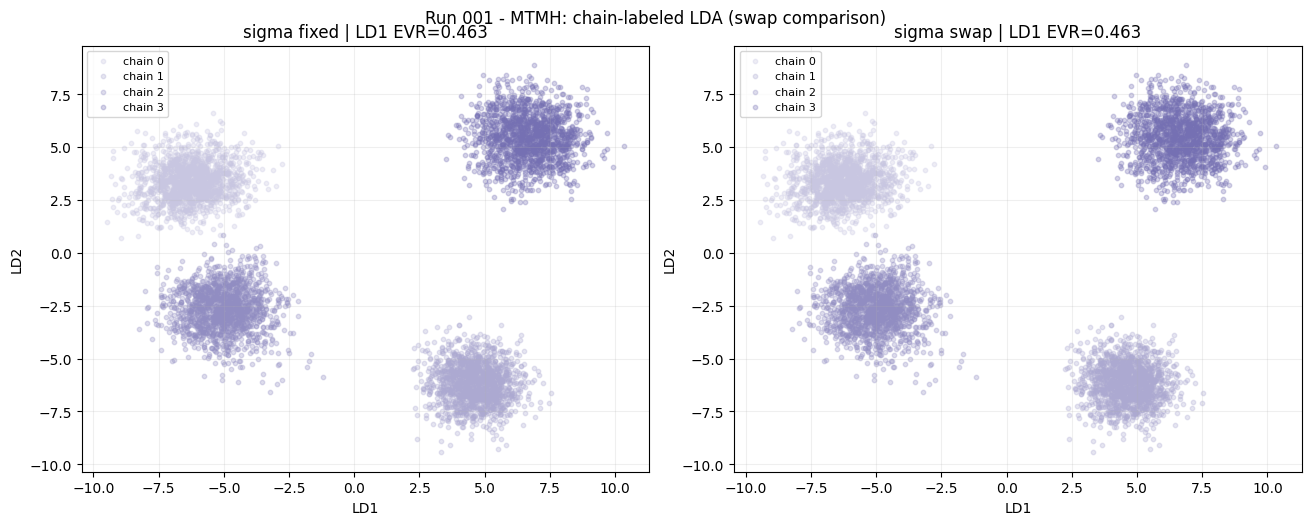

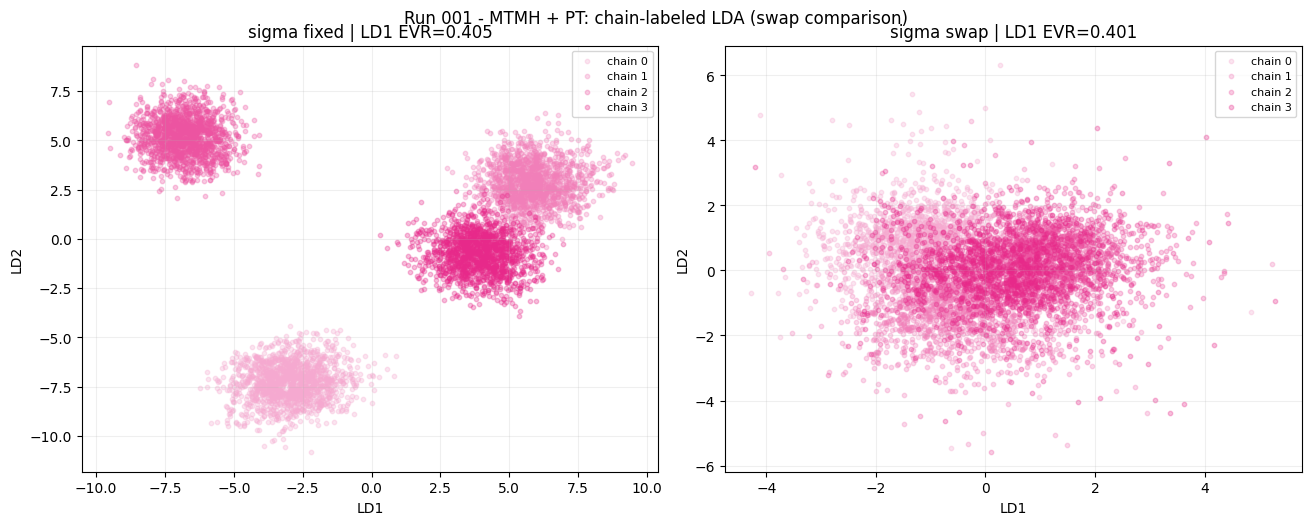

In [6]:
# Swap comparison: fixed run + method, compare swap/no-swap side by side
for run_id in RUN_IDS:
    for method in SHORT_METHODS:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

        for ax, swap_key in zip(axes, LDA_SWAP_ORDER):
            X, y, _ = _build_chain_labeled_matrix(
                swap_key=swap_key,
                run_id=run_id,
                method=method,
                max_draws_per_chain=LDA_MAX_DRAWS_PER_CHAIN,
                seed=LDA_RANDOM_SEED + run_id,
            )
            Z, model = _fit_chain_lda(X, y, n_components=2)

            chain_ids = np.unique(y)
            colors = _chain_colors_for_method(method, len(chain_ids))

            if Z.ndim == 1 or Z.shape[1] == 1:
                xvals = Z[:, 0] if Z.ndim > 1 else Z
                jitter = np.random.default_rng(0).normal(0, 0.02, size=xvals.shape[0])
                for cid, color in zip(chain_ids, colors):
                    mask = y == cid
                    ax.scatter(xvals[mask], jitter[mask], s=10, alpha=0.30, color=color, label=f"chain {cid}")
                ax.set_xlabel("LD1")
                ax.set_ylabel("jitter")
            else:
                for cid, color in zip(chain_ids, colors):
                    mask = y == cid
                    ax.scatter(Z[mask, 0], Z[mask, 1], s=10, alpha=0.30, color=color, label=f"chain {cid}")
                ax.set_xlabel("LD1")
                ax.set_ylabel("LD2")

            ld1_evr = _lda_explained_var_ld1(model)
            ld1_msg = f"LD1 EVR={ld1_evr:.3f}" if np.isfinite(ld1_evr) else "LD1 EVR=NA"
            ax.set_title(f"{_swap_name(swap_key)} | {ld1_msg}")
            ax.legend(fontsize=8)
            ax.grid(alpha=0.2)

        fig.suptitle(
            f"Run {run_id:03d} - {_method_name(method)}: chain-labeled LDA (swap comparison)",
            y=1.02,
        )
        plt.show()

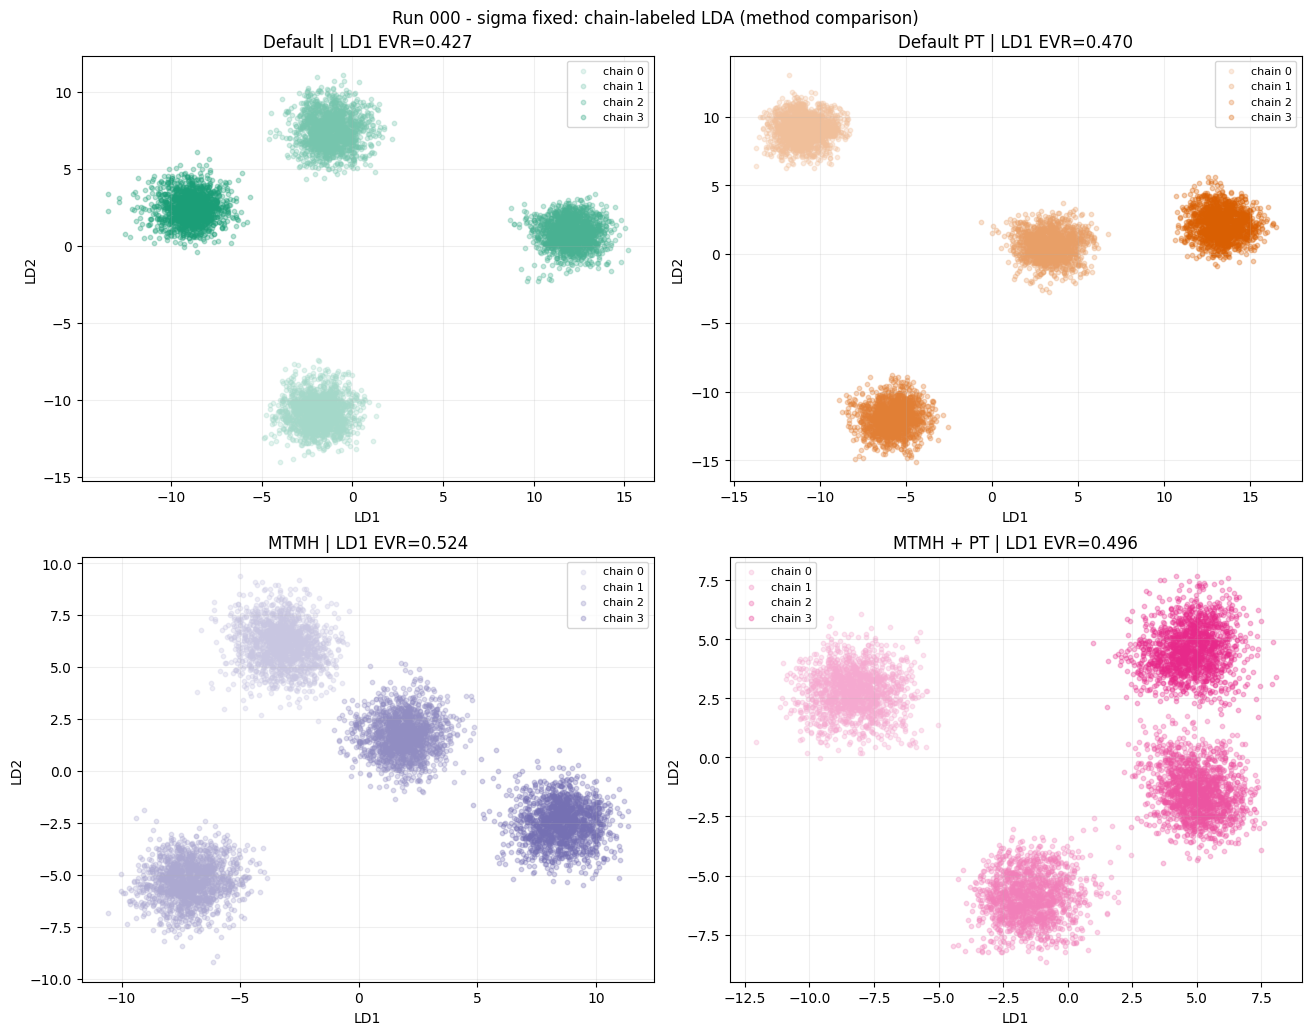

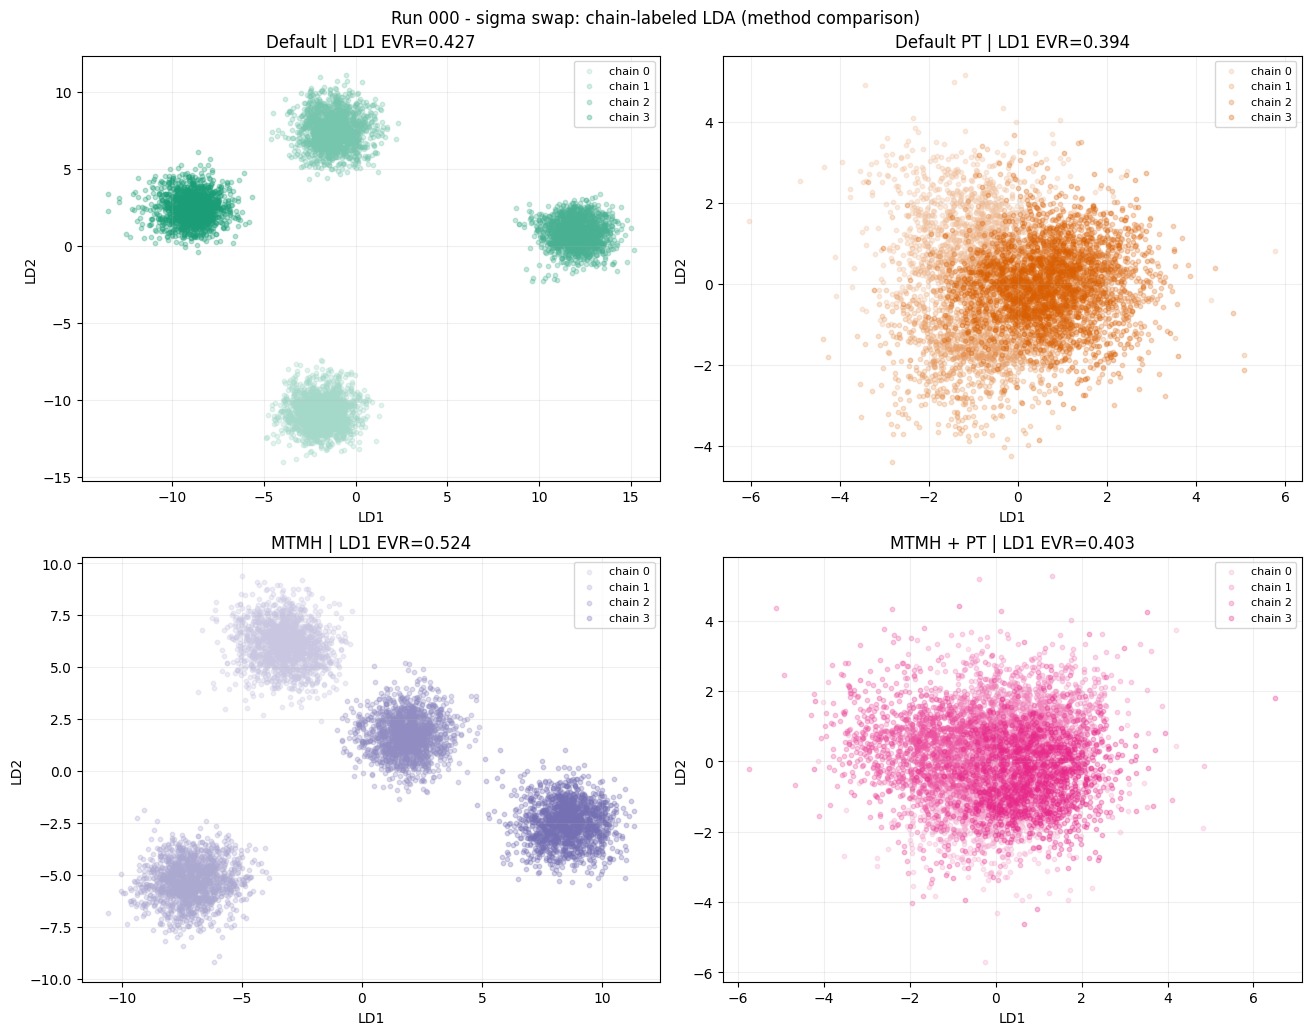

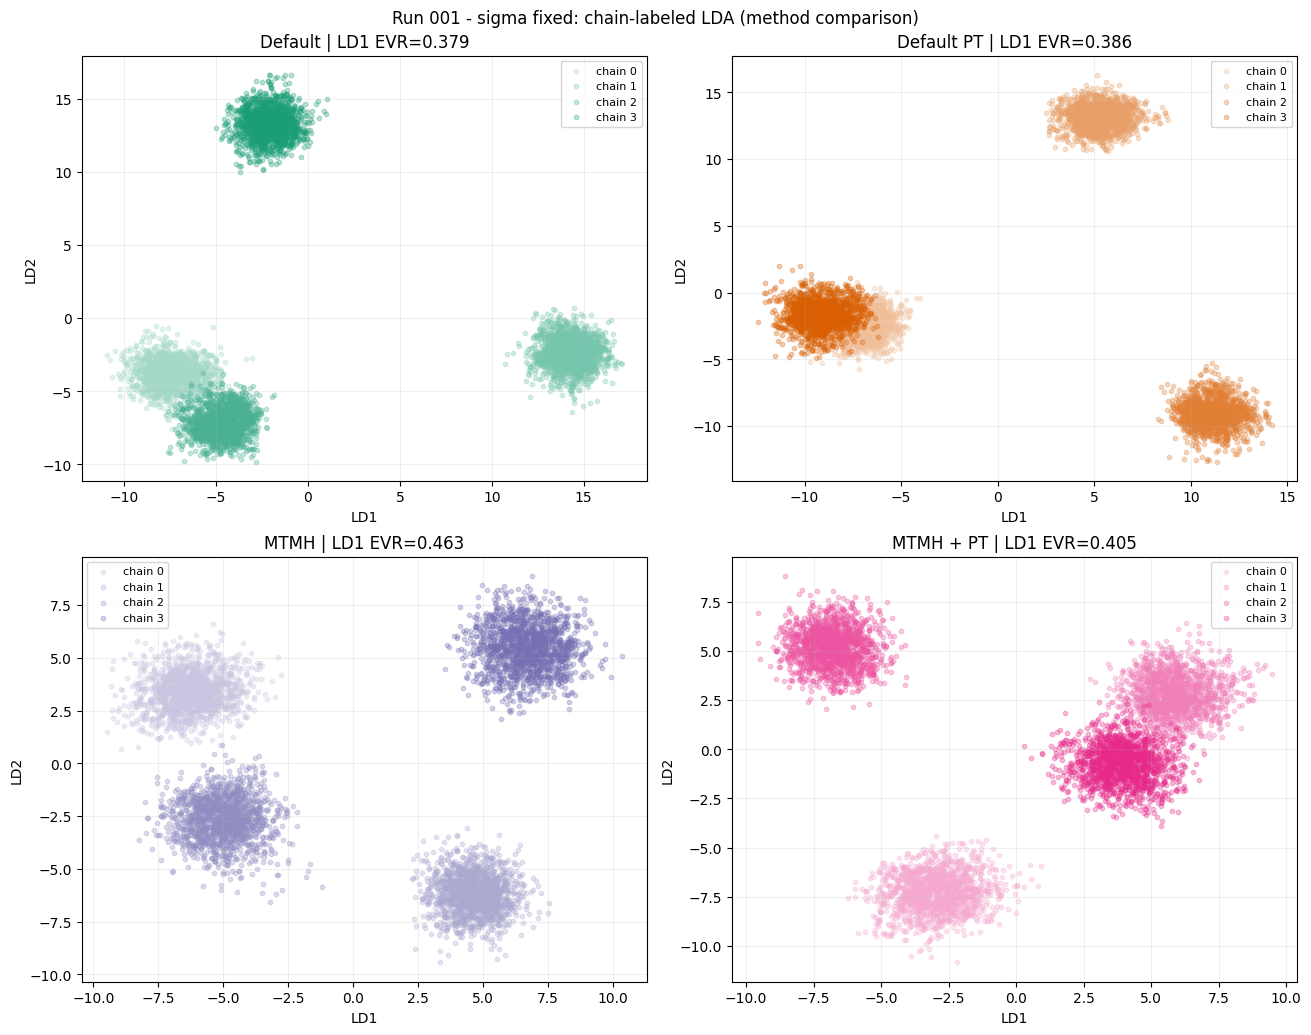

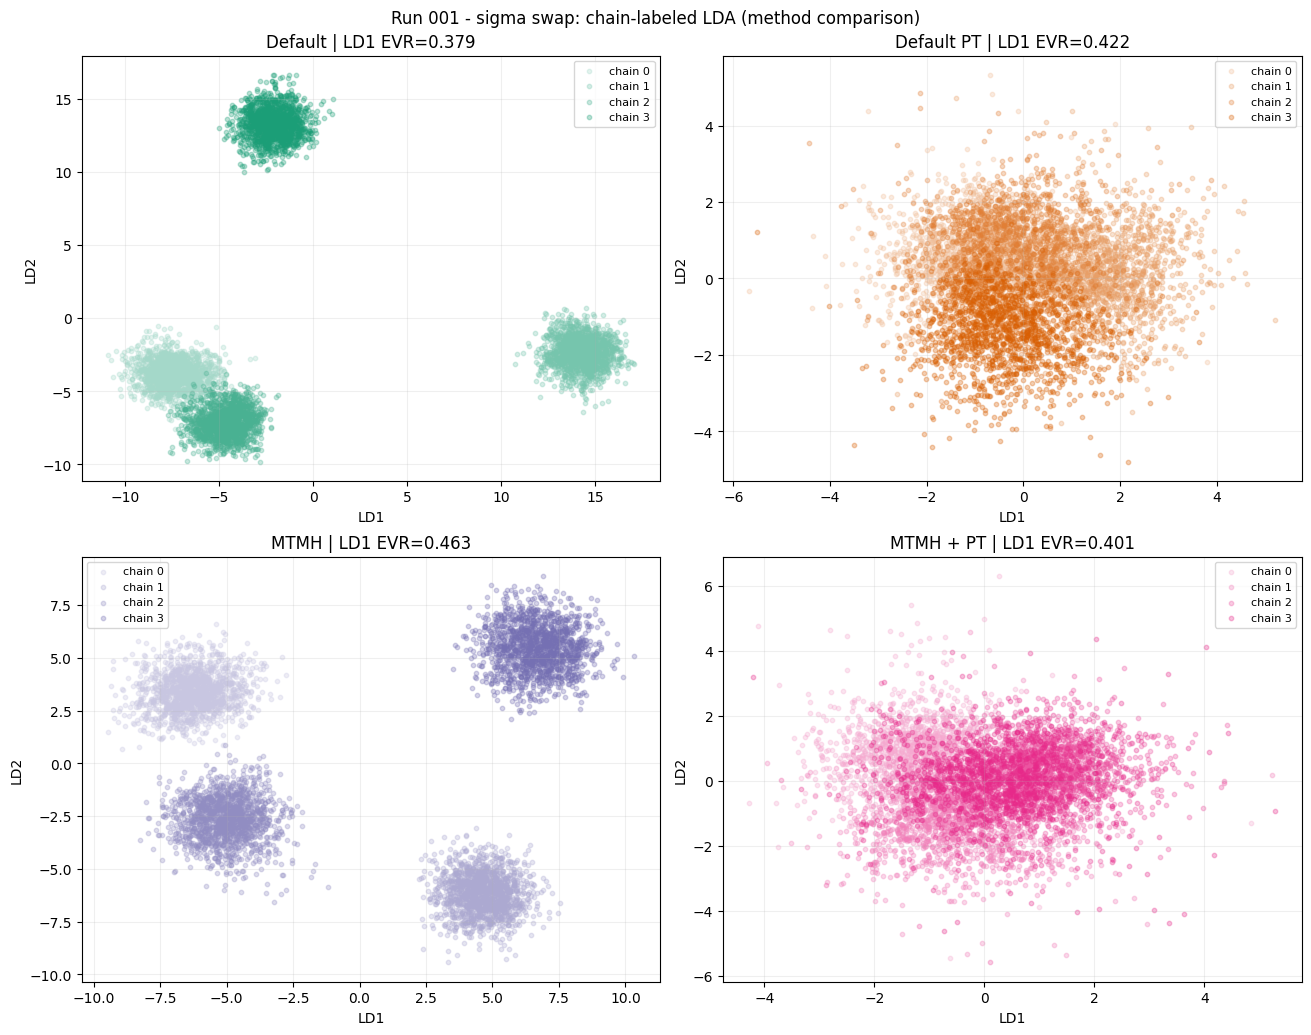

In [7]:
# Method comparison: fixed run + swap, compare four methods in a 2x2 panel
for run_id in RUN_IDS:
    for swap_key in LDA_SWAP_ORDER:
        fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

        for ax, method in zip(axes.flat, SHORT_METHODS):
            X, y, _ = _build_chain_labeled_matrix(
                swap_key=swap_key,
                run_id=run_id,
                method=method,
                max_draws_per_chain=LDA_MAX_DRAWS_PER_CHAIN,
                seed=LDA_RANDOM_SEED + run_id,
            )
            Z, model = _fit_chain_lda(X, y, n_components=2)

            chain_ids = np.unique(y)
            colors = _chain_colors_for_method(method, len(chain_ids))

            if Z.ndim == 1 or Z.shape[1] == 1:
                xvals = Z[:, 0] if Z.ndim > 1 else Z
                jitter = np.random.default_rng(0).normal(0, 0.02, size=xvals.shape[0])
                for cid, color in zip(chain_ids, colors):
                    mask = y == cid
                    ax.scatter(xvals[mask], jitter[mask], s=10, alpha=0.30, color=color, label=f"chain {cid}")
                ax.set_xlabel("LD1")
                ax.set_ylabel("jitter")
            else:
                for cid, color in zip(chain_ids, colors):
                    mask = y == cid
                    ax.scatter(Z[mask, 0], Z[mask, 1], s=10, alpha=0.30, color=color, label=f"chain {cid}")
                ax.set_xlabel("LD1")
                ax.set_ylabel("LD2")

            ld1_evr = _lda_explained_var_ld1(model)
            ld1_msg = f"LD1 EVR={ld1_evr:.3f}" if np.isfinite(ld1_evr) else "LD1 EVR=NA"
            ax.set_title(f"{_method_name(method)} | {ld1_msg}")
            ax.legend(fontsize=8)
            ax.grid(alpha=0.2)

        fig.suptitle(
            f"Run {run_id:03d} - {_swap_name(swap_key)}: chain-labeled LDA (method comparison)",
            y=1.02,
        )
        plt.show()

In [8]:
# Compact numeric summary: chain separability per (run, swap, method)
lda_rows = []

for run_id in RUN_IDS:
    for swap_key in LDA_SWAP_ORDER:
        for method in SHORT_METHODS:
            X, y, _ = _build_chain_labeled_matrix(
                swap_key=swap_key,
                run_id=run_id,
                method=method,
                max_draws_per_chain=LDA_MAX_DRAWS_PER_CHAIN,
                seed=LDA_RANDOM_SEED + run_id,
            )
            Z, model = _fit_chain_lda(X, y, n_components=2)
            metrics = _chain_separation_metrics(Z, y)

            lda_rows.append(
                {
                    "run": f"Run {run_id:03d}",
                    "swap": _swap_name(swap_key),
                    "method": _method_name(method),
                    "n_samples": int(X.shape[0]),
                    "n_features": int(X.shape[1]),
                    "ld1_explained_ratio": _lda_explained_var_ld1(model),
                    "mean_centroid_distance": metrics["mean_centroid_distance"],
                    "between_within_ratio": metrics["between_within_ratio"],
                }
            )

lda_summary_df = pd.DataFrame(lda_rows)
print("LDA chain-separation summary (bigger centroid distance / bigger between_within ratio => stronger chain separation)")
display(lda_summary_df.round(4))

print("\nMean over runs by swap + method")
display(
    lda_summary_df.groupby(["swap", "method"], as_index=False)[
        ["ld1_explained_ratio", "mean_centroid_distance", "between_within_ratio"]
    ]
    .mean()
    .round(4)
)

print("\nPivot: mean_centroid_distance")
display(
    lda_summary_df.pivot_table(
        index=["run", "swap"],
        columns="method",
        values="mean_centroid_distance",
        aggfunc="mean",
    ).round(4)
)

print("\nPivot: between_within_ratio")
display(
    lda_summary_df.pivot_table(
        index=["run", "swap"],
        columns="method",
        values="between_within_ratio",
        aggfunc="mean",
    ).round(4)
)

LDA chain-separation summary (bigger centroid distance / bigger between_within ratio => stronger chain separation)


,run,swap,method,n_samples,n_features,ld1_explained_ratio,mean_centroid_distance,between_within_ratio
0,Run 000,sigma fixed,Default,6000,100,0.4270,16.0953,51.2164
1,Run 000,sigma fixed,Default PT,6000,100,0.4703,18.8135,71.5857
2,Run 000,sigma fixed,MTMH,6000,100,0.5242,11.4230,26.5135
3,Run 000,sigma fixed,MTMH + PT,6000,100,0.4962,10.7229,23.0928
4,Run 000,sigma swap,Default,6000,100,0.4270,16.0953,51.2164
5,Run 000,sigma swap,Default PT,6000,100,0.3937,1.8713,0.7133
6,Run 000,sigma swap,MTMH,6000,100,0.5242,11.4230,26.5135
7,Run 000,sigma swap,MTMH + PT,6000,100,0.4026,1.8658,0.6930
8,Run 001,sigma fixed,Default,6000,100,0.3793,17.7586,66.3874
9,Run 001,sigma fixed,Default PT,6000,100,0.3860,17.8083,68.8704



Mean over runs by swap + method


,swap,method,ld1_explained_ratio,mean_centroid_distance,between_within_ratio
0,sigma fixed,Default,0.4031,16.9270,58.8019
1,sigma fixed,Default PT,0.4281,18.3109,70.2281
2,sigma fixed,MTMH,0.4937,11.5578,26.8470
3,sigma fixed,MTMH + PT,0.4503,10.7898,23.6229
4,sigma swap,Default,0.4031,16.9270,58.8019
5,sigma swap,Default PT,0.4079,1.9475,0.7797
6,sigma swap,MTMH,0.4937,11.5578,26.8470
7,sigma swap,MTMH + PT,0.4017,1.8476,0.6842



Pivot: mean_centroid_distance


method               Default  Default PT     MTMH  MTMH + PT
run     swap                                                
Run 000 sigma fixed  16.0953     18.8135  11.4230    10.7229
        sigma swap   16.0953      1.8713  11.4230     1.8658
Run 001 sigma fixed  17.7586     17.8083  11.6927    10.8567
        sigma swap   17.7586      2.0238  11.6927     1.8294


Pivot: between_within_ratio


method               Default  Default PT     MTMH  MTMH + PT
run     swap                                                
Run 000 sigma fixed  51.2164     71.5857  26.5135    23.0928
        sigma swap   51.2164      0.7133  26.5135     0.6930
Run 001 sigma fixed  66.3874     68.8704  27.1806    24.1530
        sigma swap   66.3874      0.8461  27.1806     0.6754